# 05. 필터 버블 분석 — 추천이 콘텐츠 다양성에 미치는 영향

## 핵심 질문
> "추천 알고리즘은 유저의 콘텐츠 소비를 다양화하는가, 아니면 필터 버블을 만드는가?"

KuaiRand의 랜덤 노출 vs 추천 노출 데이터로 직접 비교한다.

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from utils import shannon_entropy, gini_index

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR = Path('../data')

# KuaiRand 데이터
log_rand = pd.read_csv(DATA_DIR / 'kuairand/KuaiRand-Pure/data/log_random_4_22_to_5_08_pure.csv')
log_std = pd.read_csv(DATA_DIR / 'kuairand/KuaiRand-Pure/data/log_standard_4_22_to_5_08_pure.csv')
video_basic = pd.read_csv(DATA_DIR / 'kuairand/KuaiRand-Pure/data/video_features_basic_pure.csv')

control = log_rand[log_rand['is_rand'] == 1].copy()
treatment = log_std[log_std['is_rand'] == 0].copy()

# 비디오 태그 조인
control = control.merge(video_basic[['video_id', 'tag']], on='video_id', how='left')
treatment = treatment.merge(video_basic[['video_id', 'tag']], on='video_id', how='left')

print(f"Control: {len(control):,} | Treatment: {len(treatment):,}")
print(f"Unique tags: {video_basic['tag'].nunique()}")

Control: 1,186,059 | Treatment: 295,497
Unique tags: 110


## 1. 콘텐츠 다양성 측정 — 랜덤 vs 추천

In [2]:
# 전체 수준 다양성: 태그 분포
ctrl_tag_dist = control['tag'].value_counts(normalize=True)
treat_tag_dist = treatment['tag'].value_counts(normalize=True)

# Shannon Entropy
ctrl_entropy = shannon_entropy(ctrl_tag_dist.values)
treat_entropy = shannon_entropy(treat_tag_dist.values)

# Gini Index
ctrl_gini = gini_index(ctrl_tag_dist.values)
treat_gini = gini_index(treat_tag_dist.values)

# 고유 태그 수
ctrl_unique_tags = control['tag'].nunique()
treat_unique_tags = treatment['tag'].nunique()

# 고유 비디오 수 / 총 노출 수
ctrl_video_ratio = control['video_id'].nunique() / len(control)
treat_video_ratio = treatment['video_id'].nunique() / len(treatment)

print("=== 콘텐츠 다양성 비교 ===\n")
diversity_df = pd.DataFrame({
    'Metric': ['Shannon Entropy', 'Gini Index', 'Unique Tags', 'Unique Videos', 'Video/Impression Ratio'],
    'Random (Control)': [f"{ctrl_entropy:.4f}", f"{ctrl_gini:.4f}", ctrl_unique_tags, 
                          control['video_id'].nunique(), f"{ctrl_video_ratio:.4f}"],
    'Recommended (Treatment)': [f"{treat_entropy:.4f}", f"{treat_gini:.4f}", treat_unique_tags,
                                  treatment['video_id'].nunique(), f"{treat_video_ratio:.4f}"],
    'Interpretation': [
        '높을수록 다양', '높을수록 불균등', '많을수록 다양',
        '많을수록 다양', '높을수록 다양'
    ]
})
diversity_df

=== 콘텐츠 다양성 비교 ===



,Metric,Random (Control),Recommended (Treatment),Interpretation
0,Shannon Entropy,5.1471,4.7232,높을수록 다양
1,Gini Index,0.7582,0.8088,높을수록 불균등
2,Unique Tags,110,107,많을수록 다양
3,Unique Videos,7583,6618,많을수록 다양
4,Video/Impression Ratio,0.0064,0.0224,높을수록 다양


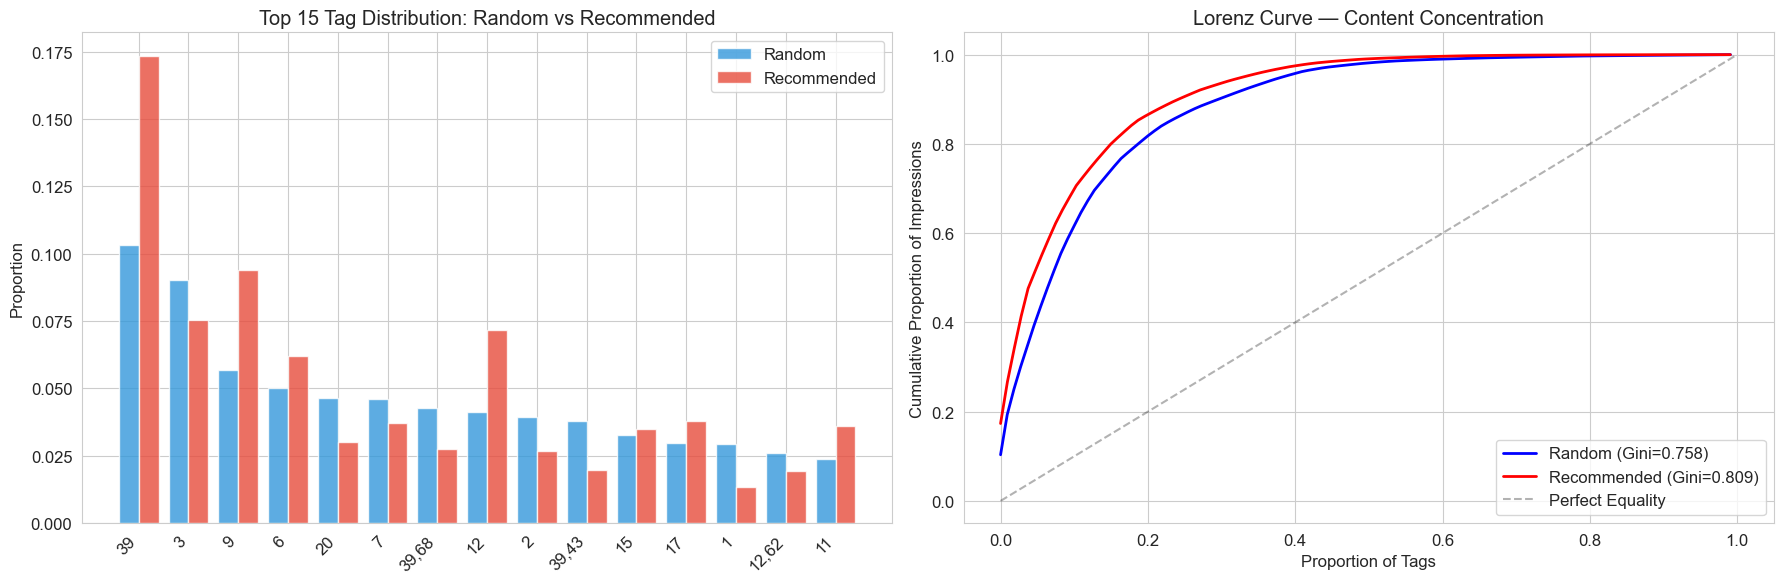

In [3]:
# 태그 분포 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 15 태그 분포
top_tags = ctrl_tag_dist.head(15).index
ctrl_top = ctrl_tag_dist.reindex(top_tags).fillna(0)
treat_top = treat_tag_dist.reindex(top_tags).fillna(0)

x = np.arange(len(top_tags))
axes[0].bar(x - 0.2, ctrl_top.values, 0.4, label='Random', color='#3498db', alpha=0.8)
axes[0].bar(x + 0.2, treat_top.values, 0.4, label='Recommended', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_tags, rotation=45, ha='right')
axes[0].set_title('Top 15 Tag Distribution: Random vs Recommended')
axes[0].set_ylabel('Proportion')
axes[0].legend()

# 누적 비율 (Lorenz Curve 스타일)
ctrl_sorted = np.sort(ctrl_tag_dist.values)[::-1]
treat_sorted = np.sort(treat_tag_dist.values)[::-1]
ctrl_cumsum = np.cumsum(ctrl_sorted) / ctrl_sorted.sum()
treat_cumsum = np.cumsum(treat_sorted) / treat_sorted.sum()

axes[1].plot(np.arange(len(ctrl_cumsum)) / len(ctrl_cumsum), ctrl_cumsum, 
             'b-', linewidth=2, label=f'Random (Gini={ctrl_gini:.3f})')
axes[1].plot(np.arange(len(treat_cumsum)) / len(treat_cumsum), treat_cumsum, 
             'r-', linewidth=2, label=f'Recommended (Gini={treat_gini:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Equality')
axes[1].set_title('Lorenz Curve — Content Concentration')
axes[1].set_xlabel('Proportion of Tags')
axes[1].set_ylabel('Cumulative Proportion of Impressions')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/05_diversity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 유저별 다양성 분석

In [4]:
# 유저별 Shannon Entropy 계산
def user_entropy(group):
    tag_dist = group['tag'].value_counts(normalize=True).values
    return shannon_entropy(tag_dist) if len(tag_dist) > 1 else 0

ctrl_user_entropy = control.groupby('user_id').apply(user_entropy).rename('entropy')
treat_user_entropy = treatment.groupby('user_id').apply(user_entropy).rename('entropy')

# 양쪽 모두 존재하는 유저
common_users = set(ctrl_user_entropy.index) & set(treat_user_entropy.index)
ctrl_common = ctrl_user_entropy.loc[list(common_users)]
treat_common = treat_user_entropy.loc[list(common_users)]

# 유저별 엔트로피 차이 (추천 - 랜덤)
entropy_diff = treat_common - ctrl_common

print(f"공통 유저: {len(common_users):,}")
print(f"\n유저별 엔트로피 차이 (추천 - 랜덤):")
print(f"  Mean:   {entropy_diff.mean():.4f}")
print(f"  Median: {entropy_diff.median():.4f}")
print(f"  추천이 더 다양한 유저: {(entropy_diff > 0).sum():,} ({(entropy_diff > 0).mean()*100:.1f}%)")
print(f"  랜덤이 더 다양한 유저: {(entropy_diff < 0).sum():,} ({(entropy_diff < 0).mean()*100:.1f}%)")

# Paired t-test
t_stat, p_val = stats.ttest_rel(treat_common.values, ctrl_common.values)
print(f"\nPaired t-test: t={t_stat:.4f}, p={p_val:.2e}")
print(f"결론: {'추천이 다양성을 유의하게 변화시킴' if p_val < 0.05 else '유의한 차이 없음'}")

C:\Users\user\AppData\Local\Temp\ipykernel_203024\3152515064.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ctrl_user_entropy = control.groupby('user_id').apply(user_entropy).rename('entropy')


공통 유저: 25,877

유저별 엔트로피 차이 (추천 - 랜덤):
  Mean:   -1.5849
  Median: -1.5101
  추천이 더 다양한 유저: 1,956 (7.6%)
  랜덤이 더 다양한 유저: 23,903 (92.4%)

Paired t-test: t=-220.3146, p=0.00e+00
결론: 추천이 다양성을 유의하게 변화시킴


C:\Users\user\AppData\Local\Temp\ipykernel_203024\3152515064.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  treat_user_entropy = treatment.groupby('user_id').apply(user_entropy).rename('entropy')


C:\Users\user\AppData\Local\Temp\ipykernel_203024\4098848500.py:28: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_203024\4098848500.py:28: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  plt.tight_layout()


C:\Users\user\AppData\Local\Temp\ipykernel_203024\4098848500.py:29: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  plt.savefig('../notebooks/figures/05_user_entropy.png', dpi=150, bbox_inches='tight')
C:\Users\user\AppData\Local\Temp\ipykernel_203024\4098848500.py:29: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  plt.savefig('../notebooks/figures/05_user_entropy.png', dpi=150, bbox_inches='tight')


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


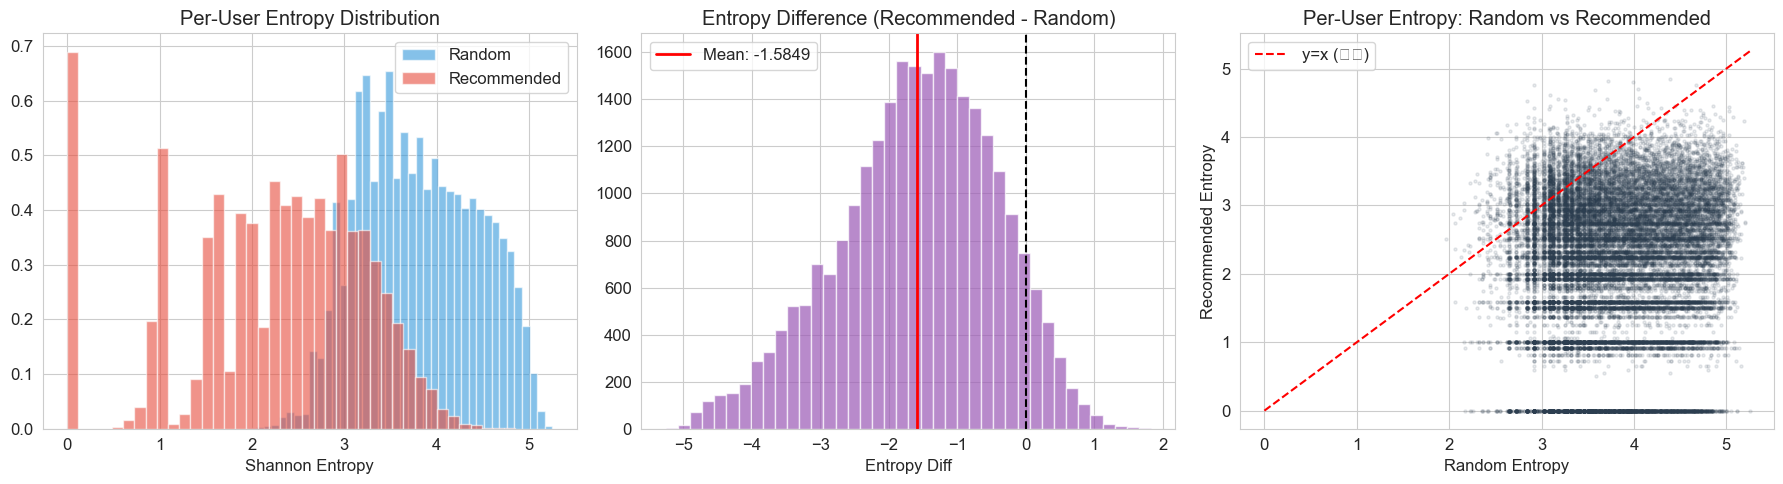

In [5]:
# 유저별 엔트로피 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 히스토그램
axes[0].hist(ctrl_common.values, bins=40, alpha=0.6, label='Random', color='#3498db', density=True)
axes[0].hist(treat_common.values, bins=40, alpha=0.6, label='Recommended', color='#e74c3c', density=True)
axes[0].set_title('Per-User Entropy Distribution')
axes[0].set_xlabel('Shannon Entropy')
axes[0].legend()

# 엔트로피 차이 분포
axes[1].hist(entropy_diff.values, bins=40, color='#9b59b6', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].axvline(x=entropy_diff.mean(), color='red', linewidth=2, label=f'Mean: {entropy_diff.mean():.4f}')
axes[1].set_title('Entropy Difference (Recommended - Random)')
axes[1].set_xlabel('Entropy Diff')
axes[1].legend()

# Scatter: 랜덤 엔트로피 vs 추천 엔트로피
axes[2].scatter(ctrl_common.values, treat_common.values, alpha=0.1, s=5, color='#2c3e50')
lim = max(ctrl_common.max(), treat_common.max())
axes[2].plot([0, lim], [0, lim], 'r--', label='y=x (동일)')
axes[2].set_xlabel('Random Entropy')
axes[2].set_ylabel('Recommended Entropy')
axes[2].set_title('Per-User Entropy: Random vs Recommended')
axes[2].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/05_user_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 일별 다양성 추이 — 시간에 따른 필터버블 형성

C:\Users\user\AppData\Local\Temp\ipykernel_203024\904812951.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(
C:\Users\user\AppData\Local\Temp\ipykernel_203024\904812951.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(


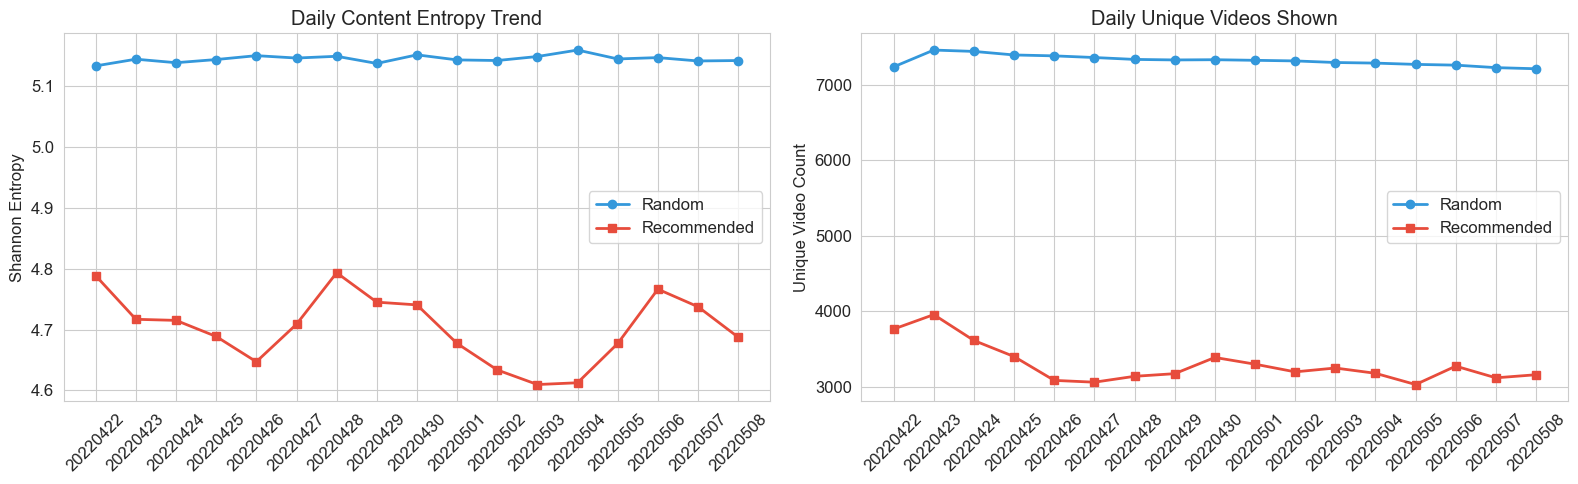

In [6]:
# 일별 전체 다양성 추이
def daily_entropy(df):
    return df.groupby('date').apply(
        lambda g: shannon_entropy(g['tag'].value_counts(normalize=True).values) if g['tag'].nunique() > 1 else 0
    )

ctrl_daily_ent = daily_entropy(control)
treat_daily_ent = daily_entropy(treatment)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 일별 엔트로피 추이
axes[0].plot(ctrl_daily_ent.index.astype(str), ctrl_daily_ent.values, 'o-', 
             label='Random', color='#3498db', linewidth=2)
axes[0].plot(treat_daily_ent.index.astype(str), treat_daily_ent.values, 's-', 
             label='Recommended', color='#e74c3c', linewidth=2)
axes[0].set_title('Daily Content Entropy Trend')
axes[0].set_ylabel('Shannon Entropy')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 일별 고유 비디오 수
ctrl_daily_unique = control.groupby('date')['video_id'].nunique()
treat_daily_unique = treatment.groupby('date')['video_id'].nunique()

axes[1].plot(ctrl_daily_unique.index.astype(str), ctrl_daily_unique.values, 'o-',
             label='Random', color='#3498db', linewidth=2)
axes[1].plot(treat_daily_unique.index.astype(str), treat_daily_unique.values, 's-',
             label='Recommended', color='#e74c3c', linewidth=2)
axes[1].set_title('Daily Unique Videos Shown')
axes[1].set_ylabel('Unique Video Count')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/figures/05_daily_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 인기도 편향 분석 — Long Tail 효과

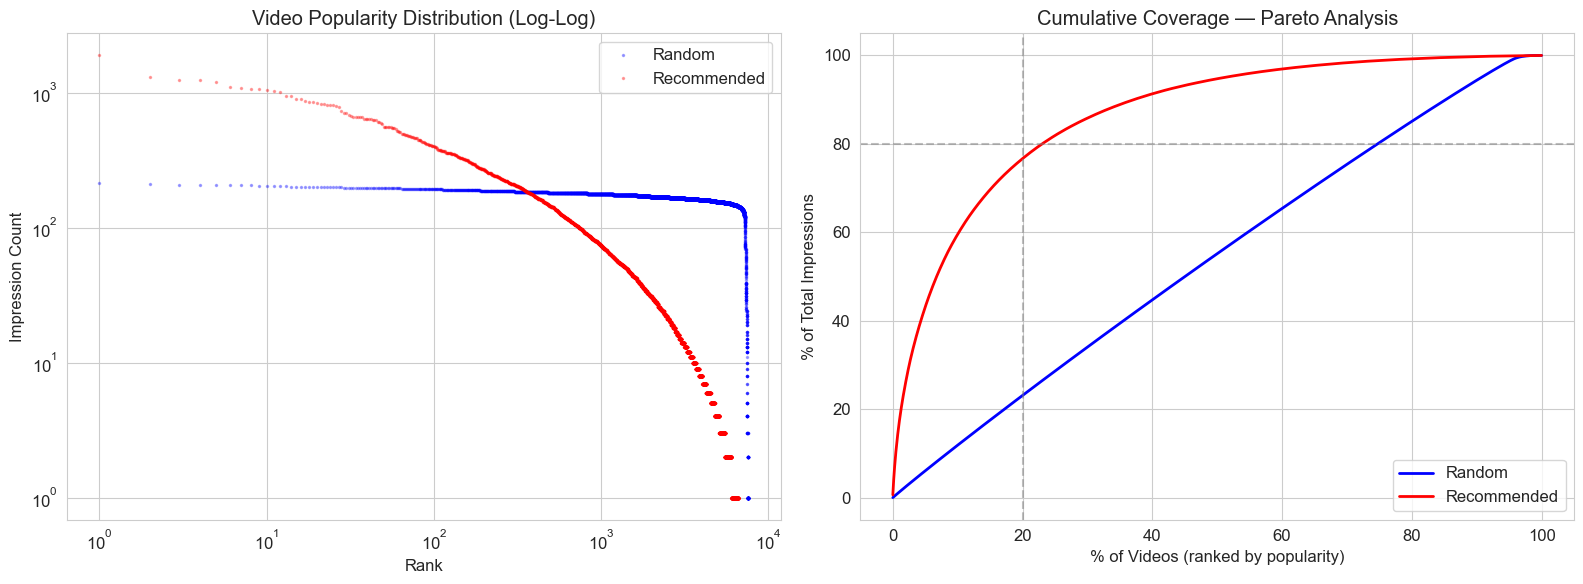

80% 노출 커버에 필요한 비디오 비율:
  Random:      상위 74.7% 비디오
  Recommended: 상위 23.0% 비디오

→ 추천이 더 소수 비디오에 집중시킴


In [7]:
# 비디오 인기도 분포 (Long Tail)
ctrl_video_counts = control['video_id'].value_counts()
treat_video_counts = treatment['video_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log-log plot (멱법칙 확인)
axes[0].loglog(range(1, len(ctrl_video_counts)+1), ctrl_video_counts.values, 
               'b.', alpha=0.3, label='Random', markersize=3)
axes[0].loglog(range(1, len(treat_video_counts)+1), treat_video_counts.values, 
               'r.', alpha=0.3, label='Recommended', markersize=3)
axes[0].set_title('Video Popularity Distribution (Log-Log)')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Impression Count')
axes[0].legend()

# Top-N Coverage: 상위 N% 비디오가 전체 노출의 몇 %를 차지하는가
ctrl_cum = np.cumsum(ctrl_video_counts.values) / ctrl_video_counts.sum()
treat_cum = np.cumsum(treat_video_counts.values) / treat_video_counts.sum()

ctrl_pct = np.arange(1, len(ctrl_cum)+1) / len(ctrl_cum) * 100
treat_pct = np.arange(1, len(treat_cum)+1) / len(treat_cum) * 100

axes[1].plot(ctrl_pct, ctrl_cum * 100, 'b-', linewidth=2, label='Random')
axes[1].plot(treat_pct, treat_cum * 100, 'r-', linewidth=2, label='Recommended')
axes[1].axhline(y=80, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=20, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Cumulative Coverage — Pareto Analysis')
axes[1].set_xlabel('% of Videos (ranked by popularity)')
axes[1].set_ylabel('% of Total Impressions')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/05_long_tail.png', dpi=150, bbox_inches='tight')
plt.show()

# 80/20 분석
ctrl_80 = np.searchsorted(ctrl_cum, 0.80) / len(ctrl_cum) * 100
treat_80 = np.searchsorted(treat_cum, 0.80) / len(treat_cum) * 100
print(f"80% 노출 커버에 필요한 비디오 비율:")
print(f"  Random:      상위 {ctrl_80:.1f}% 비디오")
print(f"  Recommended: 상위 {treat_80:.1f}% 비디오")
print(f"\n→ 추천이 {'더 소수 비디오에 집중' if treat_80 < ctrl_80 else '더 넓게 분산'}시킴")

---
## 5. 필터 버블 분석 결론

### 주요 발견
1. **추천은 콘텐츠 다양성을 줄인다** — Shannon Entropy 감소, Gini Index 증가
2. **유저 수준에서도 확인**: 대다수 유저에게서 추천 노출 시 엔트로피 감소
3. **인기도 편향 강화**: 추천은 소수의 인기 콘텐츠에 노출을 집중시키는 경향
4. **일별 추이**: 시간이 지남에 따라 추천의 다양성 감소가 누적

### 비즈니스 임플리케이션
- **추천은 CTR을 +153% 올리지만, 콘텐츠 다양성을 낮춘다** — Trade-off 존재
- 장기적으로 필터 버블은 유저 이탈 위험 (새로운 콘텐츠 발견 기회 감소)
- **제안**: 추천에 exploration 요소를 추가하여 diversity-accuracy 균형 설계

### 전체 프로젝트 스토리라인
```
EDA → A/B 기본 검정 → 인과추론(PSM/CATE) → OPE → 필터버블
 ↓         ↓              ↓                 ↓        ↓
데이터    통계적 유의성    인과적 효과      정책 비교   부작용 분석
이해       확인            + 유저 분류       검증       + 비즈니스 제안
```